# **Special Matrices for Equity Analysis**

*In this lesson, we are going to introduce different types of matrices. These matrices play important roles in financial analysis. With sound understanding of the characteristics and operation of these matrices, you will have a good start to learn many financial analytical techniques. During the lesson, we will also use stock prices and returns as examples to demonstrate the usage of these matrices. We will use Apple, Ford Motor, and Walmart's stock returns to explain the applications of these matrices.*

## **1. Symmetric Matrices**

### **1.1. Definition of Symmetric Matrices**

A **symmetric matrix** is a square matrix whose transpose is the same as the matrix itself. A square matrix is a matrix that has the same number of rows as the number of columns. The following example demonstrates the concept of a symmetric matrix.

$$
A = \begin{bmatrix}
m & a & b \\
a & n & c \\
b & c & p
\end{bmatrix}
$$

$$
A^{T} = \begin{bmatrix}
m & a & b \\
a & n & c \\
b & c & p
\end{bmatrix}
$$

In the above example, the second matrix is the transpose of matrix \( A \). The elements of the original matrix and its transpose are the same. In mathematical notation, for matrix \( A \), if \( A = A^{T} \), then \( A \) is symmetric. More specifically, the element at position \( (i, j) \) is equal to the element at position \( (j, i) \) for all \( i \) and \( j \).

Here are some key properties of a symmetric matrix:

1. The eigenvalues of the matrix are real numbers.  
2. The eigenvectors of the matrix are orthogonal to each other.  
3. The matrix is diagonalizable.  
4. The rank of the matrix is equal to the number of non-zero eigenvalues.  

When two vectors are **orthogonal**, it means that the vectors are perpendicular to each other. It also means the inner product of the two vectors is 0. These two vectors are linearly independent.

---

### **1.2. Diagonalization of Symmetric Matrices**

Matrix \( A \) is diagonalizable if there exists a diagonal matrix \( \Lambda \) such that:

$$
A = B\Lambda B^{-1}
$$

If \( A \) is a symmetric matrix, the values on the main diagonal of \( \Lambda \) are eigenvalues of \( A \), and \( B \) is a matrix whose columns are eigenvectors of \( A \).

Let’s look at one example of diagonalization of a symmetric matrix.

We have a symmetric matrix \( M \) as follows:

$$
M = \begin{bmatrix}
6 & -2 & -1 \\
-2 & 6 & -1 \\
-1 & -1 & 5
\end{bmatrix}
$$

In order to obtain eigenvalues, we need to set the characteristic polynomial to 0:

$$
\det(M - \lambda I) = \det\left(\begin{bmatrix}
6 - \lambda & -2 & -1 \\
-2 & 6 - \lambda & -1 \\
-1 & -1 & 5 - \lambda
\end{bmatrix}\right)
$$

$$
\Downarrow
$$

$$
(6 - \lambda)(6 - \lambda)(5 - \lambda) + (-2)(-1)(-1) + (-2)(-1)(-1) - (-1)(-1)(6 - \lambda) - (-2)(-2)(5 - \lambda) - (-1)(-1)(6 - \lambda) = 0
$$

$$
\Downarrow
$$

$$
- \lambda^3 + 17\lambda^2 - 90\lambda + 144 = -(\lambda - 8)(\lambda - 6)(\lambda - 3) = 0
$$

Hence, the eigenvalues are \( \lambda_1 = 8 \), \( \lambda_2 = 6 \), and \( \lambda_3 = 3 \).

The corresponding eigenvectors are:

$$
\nu_1 = \begin{bmatrix}
-1 \\
1 \\
0
\end{bmatrix}, \quad
\nu_2 = \begin{bmatrix}
-1 \\
-1 \\
2
\end{bmatrix}, \quad
\nu_3 = \begin{bmatrix}
1 \\
1 \\
1
\end{bmatrix}
$$

The inner products of each eigenvector pair are all 0:

$$
\nu_1^{T} \nu_2 = 0, \quad \nu_2^{T} \nu_3 = 0, \quad \nu_1^{T} \nu_3 = 0
$$

This means they are orthogonal to each other.

We can further normalize the eigenvectors to unit vectors:

$$
\omega_1 = \begin{bmatrix}
- \frac{1}{\sqrt{2}} \\
\frac{1}{\sqrt{2}} \\
0
\end{bmatrix}, \quad
\omega_2 = \begin{bmatrix}
- \frac{1}{\sqrt{6}} \\
- \frac{1}{\sqrt{6}} \\
\frac{2}{\sqrt{6}}
\end{bmatrix}, \quad
\omega_3 = \begin{bmatrix}
\frac{1}{\sqrt{3}} \\
\frac{1}{\sqrt{3}} \\
\frac{1}{\sqrt{3}}
\end{bmatrix}
$$

Now we can write the diagonalized symmetric matrix \( M \) as:

$$
M = B\Lambda B^{-1}
$$

Where:

$$
\Lambda = \begin{bmatrix}
8 & 0 & 0 \\
0 & 6 & 0 \\
0 & 0 & 3
\end{bmatrix}, \quad
B = \begin{bmatrix}
- \frac{1}{\sqrt{2}} & - \frac{1}{\sqrt{6}} & \frac{1}{\sqrt{3}} \\
\frac{1}{\sqrt{2}} & - \frac{1}{\sqrt{6}} & \frac{1}{\sqrt{3}} \\
0 & \frac{2}{\sqrt{6}} & \frac{1}{\sqrt{3}}
\end{bmatrix}
$$

Because \( B \) is an orthogonal matrix, \( B^{T} = B^{-1} \). So we can also write:

$$
M = B\Lambda B^{T}
$$

Transforming a symmetric matrix to diagonalized form makes matrix computations more efficient. It also helps decompose a matrix into simpler forms for analysis. Diagonalization is an essential tool for solving linear transformations.

Now that we have learned many properties of symmetric matrices, let’s take a look at some common symmetric matrices, like the **covariance matrix** and the **correlation matrix**. We’ll begin with the covariance matrix.

### **1.3. Covariance Matrix**
We introduced the covariance matrix in the previous lesson. A covariance matrix is a square matrix giving the variances of the variables on the diagonal of the matrix and the covariances between each pair of the variables on the off-diagonal. Based on the structure of a covariance matrix, it is a symmetric matrix. Let's calculate the covariance matrix for stock returns for Apple, Ford Motor, and Walmart as an example.

In [1]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yfin
import seaborn as sns

In [2]:
# Download stock prices from Yahoo Finance and set the time period for download
start = datetime.date(2018, 1, 2)
end = datetime.date(2023, 12, 31)
stocks = yfin.download(["AAPL", "F", "WMT"], start, end, auto_adjust = False)["Adj Close"]
stocks.head()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,F,WMT
Date,,,
2018-01-02,40.426826,8.470925,29.041025
2018-01-03,40.419781,8.537842,29.294357
2018-01-04,40.607533,8.685044,29.320862
2018-01-05,41.069870,8.832249,29.494654
2018-01-08,40.917313,8.798792,29.930613


In [3]:
stocks.index = pd.to_datetime(stocks.index).strftime("%Y-%m-%d")

In [4]:
# In order to calculate the returns of the stocks, we need to drop the NA rows.
stocks_returns = stocks[["AAPL", "F", "WMT"]].dropna().pct_change()
stocks_returns = stocks_returns.dropna()
stocks_returns.head()

Ticker,AAPL,F,WMT
Date,,,
2018-01-03,-0.000174,0.007900,0.008723
2018-01-04,0.004645,0.017241,0.000905
2018-01-05,0.011386,0.016949,0.005927
2018-01-08,-0.003715,-0.003788,0.014781
2018-01-09,-0.000115,-0.005323,-0.012007


With the stock returns for Apple, Ford Motor and Walmart, we can calculate the covariance matrix for the 3 stock returns.

In [5]:
# Calculate covariance matrix for Apple, Ford Motor and Walmart
# Use np.allclose to verify if the matrix is a symmetric matrix
stock_returns_covariance_matrix = stocks_returns.cov()
print("Apple, Ford Motor and Walmart Covariance Matrix:")
print(stock_returns_covariance_matrix)
print("\nIs the covariance matrix symmetric?", np.allclose(stock_returns_covariance_matrix, stock_returns_covariance_matrix.T))

Apple, Ford Motor and Walmart Covariance Matrix:
Ticker      AAPL         F       WMT
Ticker                              
AAPL    0.000398  0.000194  0.000103
F       0.000194  0.000668  0.000068
WMT     0.000103  0.000068  0.000199

Is the covariance matrix symmetric? True


As we can see from the above covariance matrix for Apple, Ford Motor, and Walmart, the variances of the three stocks are on the diagonal of the matrix. The covariances of any pairs of the stocks are on the off-diagonal of the matrix. This covariance matrix is also a symmetric matrix based on the definition.
<br>
<br>
### **1.4. Correlation Matrix**
According to the previous lesson, correlation is a metric to measure the co-movement of two variables while removing their scales. Without the scale difference, we can compare correlations from different pairs of variables. It is also a symmetric matrix. Let's continue our Apple, Ford Motor, and Walmart stock return example to calculate their correlation matrix.

In [6]:
# Calculate correlation matrix for Apple, Ford Motor and Walmart
# Verify if a correlation matrix a symmetric matrix
stock_returns_correlation_matrix = stocks_returns.corr()
print("Apple, Ford Motor and Walmart Correlation Matrix:")
print(stock_returns_correlation_matrix)
print("\nIs the correlation matrix symmetric?", np.allclose(stock_returns_correlation_matrix, stock_returns_correlation_matrix.T))

Apple, Ford Motor and Walmart Correlation Matrix:
Ticker      AAPL         F       WMT
Ticker                              
AAPL    1.000000  0.376460  0.365246
F       0.376460  1.000000  0.185248
WMT     0.365246  0.185248  1.000000

Is the correlation matrix symmetric? True


We can see from the above correlation matrix that it is also a symmetric matrix. The diagonal values are the correlations of 3 stocks to themselves. The off-diagonal values are the correlations of different paired stock returns. Apple's stock return has similar correlation to both Ford Motor and Walmart's stock returns. Ford Motor and Walmart's stock returns have the lowest correlation among other stock return pairs.
<br>
<br>
### **1.5. Converting between Covariance and Correlation Matrices**
From the previous lesson, we learned that covariance and correlation have the following relationship.
<br>
<br>
$$Corr(𝑋,𝑌)=\frac{Cov(𝑋,𝑌)}{ \sqrt{Var(𝑋)} * \sqrt{Var(𝑌)}}$$
<br>
where $Cov(X,Y)$ is the covariance of $X$ and $Y$, $Var(X)$ and $Var(Y)$ are variances of $X$ and $Y$.
<br>
<br>
We can use the above formula to convert between covariance and correlation matrices easily. Let's demonstrate the conversion with the following code.

In [7]:
# Convert covariance to correlation
def cov_to_corr(cov_matrix):
    d = np.sqrt(np.diag(cov_matrix))
    corr_matrix = cov_matrix / np.outer(d, d)
    return corr_matrix

# Convert correlation to covariance
def corr_to_cov(corr_matrix, std_devs):
    cov_matrix = corr_matrix * np.outer(std_devs, std_devs)
    return cov_matrix

In [8]:
# Use our Apple, Ford Motor and Walmart stock returns example to demonstrate the conversion
# Calculate standard deviations of stock returns
stocks_returns_std = stocks_returns.std()

#convert covariance to correlation example
cov_to_corr(stock_returns_correlation_matrix)

Ticker,AAPL,F,WMT
Ticker,,,
AAPL,1.000000,0.376460,0.365246
F,0.376460,1.000000,0.185248
WMT,0.365246,0.185248,1.000000


In [9]:
#convert correlation to covariance example
corr_to_cov(stock_returns_correlation_matrix, stocks_returns_std)

Ticker,AAPL,F,WMT
Ticker,,,
AAPL,0.000398,0.000194,0.000103
F,0.000194,0.000668,0.000068
WMT,0.000103,0.000068,0.000199


## **2. Triangular Matrix**
Another commonly used matrix is the triangular matrix. A triangular matrix is a square matrix where all the entries on one side of the main diagonal are zero. There are two types of triangular matrices: lower triangular matrix and upper triangular matrix.
<br>
<br>
### **2.1. Lower Triangular Matrix**
A **lower triangular matrix** is a square matrix whose entries above the main diagonal are zero. The main diagonal and entries below it can be any value. Below is a demonstration of a lower triangular matrix.
<br>
<br>
$$B = \begin{bmatrix}
m & 0 & 0 \\
a & n & 0 \\
b & c & p
\end{bmatrix}$$
<br>
<br>
### **2.2. Upper Triangular Matrix**

An **upper triangular matrix** is a square matrix whose entries below the main diagonal are zero. The main diagonal and entries above it can be any value. Below is a demonstration of an upper triangular matrix.
<br>
<br>
$$B = \begin{bmatrix}
m & a & b \\
0 & n & c \\
0 & 0 & p
\end{bmatrix}$$
<br>
<br>
### **2.3. Properties of a Triangular Matrix**
Here are some key properties of a triangular matrix:
<br>
<br>
&emsp;&emsp;1. The determinant is the product of the diagonal elements.
<br>
&emsp;&emsp;2. The inverse of a triangular matrix (if it exists) is also triangular.
<br>
&emsp;&emsp;3. The product of two upper (or lower) triangular matrices is upper (or lower) triangular.

The above properties are all very easy to prove using matrix operations, so we will leave these proofs to the readers.

## **3. Symmetric Positive Definite (PD) Matrices and Symmetric Positive Semi-Definite (SPD) Matrices**

In this section, we are going to introduce two important types of matrices: **symmetric positive definite (PD)** matrices and **symmetric positive semi-definite (SPD)** matrices.

---

### **3.1. Symmetric Positive Definite (PD) Matrices**

A symmetric matrix \( A \) is **positive definite** if:

$$
x^{T} A x > 0 \quad \text{for all non-zero vectors } x
$$

#### Key properties of a symmetric positive definite matrix:

1. All eigenvalues of the matrix are positive  
2. The determinant of the matrix is positive  
3. The matrix has full rank  
4. The matrix is invertible  
5. The sum and product (in certain contexts) of two symmetric positive definite matrices are also symmetric positive definite  

These properties—full rank, positive determinant, and positive eigenvalues—are deeply interconnected. Symmetric positive definite matrices are widely used due to their guarantees of **non-singularity**, **stability**, and **convergence** in numerical methods and optimization problems.

#### Example:

Consider the symmetric matrix:

$$
\begin{bmatrix}
3 & 4 \\
4 & 5
\end{bmatrix}
$$

This matrix is symmetric. However, the determinant is:

$$
(3 \times 5) - (4 \times 4) = 15 - 16 = -1
$$

Since the determinant is negative, the matrix is **not positive definite**.

---

### **3.2. Symmetric Positive Semidefinite (SPD) Matrices**

A symmetric matrix \( A \) is **positive semidefinite** if:

$$
x^{T} A x \ge 0 \quad \text{for all vectors } x
$$

#### Key properties of a symmetric positive semidefinite matrix:

1. All eigenvalues are **non-negative**  
2. The determinant is **non-negative**  
3. The matrix **may not** have full rank  
4. The matrix is **not always invertible**

We often use the **determinant** as a quick indicator. If the determinant is **non-negative**, the matrix might be positive semidefinite (though this is not a sufficient condition on its own—it should be verified via eigenvalues or the definition above).

#### Example:

Consider the matrix:

$$
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
$$

This is a symmetric matrix. The determinant is 0, so the matrix is **positive semidefinite**, but **not** positive definite.

---

### **Covariance and Correlation Matrices**

Both **covariance** and **correlation matrices** are:

- **Symmetric**
- **Positive semidefinite**, but not necessarily **positive definite**

This means they may have **zero eigenvalues**, especially when variables are linearly dependent.

---

### **Python Snippet to Check for PD/SPD**

Here's a simple Python function you can use in Jupyter to check whether a matrix is symmetric positive definite or positive semidefinite:

```python
import numpy as np

def check_matrix_type(A):
    # Check symmetry
    if not np.allclose(A, A.T):
        return "Matrix is not symmetric."
    
    # Check eigenvalues
    eigvals = np.linalg.eigvalsh(A)
    
    if np.all(eigvals > 0):
        return "Matrix is Symmetric Positive Definite (PD)"
    elif np.all(eigvals >= 0):
        return "Matrix is Symmetric Positive Semidefinite (SPD)"
    else:
        return "Matrix is Symmetric but not Positive Definite or Semidefinite"

# Example usage:
A = np.array([[1, 1, 1],
              [1, 1, 1],
              [1, 1, 1]])

print(check_matrix_type(A))

In [10]:
def is_positive_definite(matrix):
    return np.all(np.linalg.eigvals(matrix) > 0)

A = stock_returns_correlation_matrix

print("Is A positive definite?", is_positive_definite(A))
print("Eigenvalues:", np.linalg.eigvals(A))
print("Determinant:", np.linalg.det(A))
print("Rank:", np.linalg.matrix_rank(A))

Is A positive definite? True
Eigenvalues: [1.62523837 0.55989723 0.8148644 ]
Determinant: 0.7414992737848202
Rank: 3


In [11]:
def is_positive_semidefinite(matrix):
    return np.all(np.linalg.eigvals(matrix) >= 0)

A = stock_returns_correlation_matrix

print("Is A positive semidefinite?", is_positive_semidefinite(A))
print("Eigenvalues:", np.linalg.eigvals(A))
print("Determinant:", np.linalg.det(A))
print("Rank:", np.linalg.matrix_rank(A))

Is A positive semidefinite? True
Eigenvalues: [1.62523837 0.55989723 0.8148644 ]
Determinant: 0.7414992737848202
Rank: 3


## **4. Cholesky Factorization**
### **4.1. Definition of Cholesky Factorization**
**Cholesky factorization** is a method to decompose a symmetric matrix. Cholesky factorization states that a symmetric positive definite matrix $S$ can be decomposed as follows:
<br>
$$S = LL^{T}$$

where $L$ is a lower triangular matrix or a Cholesky factor.
<br>
<br>
Let's look at a numeric example. Suppose we have the following $3\times 3$ symmetric positive definite matrix.
<br>
<br>
$$S =\begin{bmatrix}
s_{11} & s_{21} & s_{31} \\
s_{21} & s_{22} & s_{32} \\
s_{31} & s_{23} & s_{33}
\end{bmatrix}=\begin{bmatrix}
l_{11} & 0 & 0 \\
1_{21} & l_{22} & 0 \\
l_{31} & l_{32} & l_{33}
\end{bmatrix}\begin{bmatrix}
l_{11} & l_{21} & l_{31} \\
0 & l_{22} & l_{32} \\
0 & 0 & l_{33}
\end{bmatrix}=LL^{T}$$
<br>
$$\Downarrow $$
<br>
<br>
$$LL^{T}=\begin{bmatrix}
l_{11}^{2} & l_{11}l_{21} & l_{11}l_{13} \\
l_{21}l_{11} & l_{21}^{2} +l_{22}^{2}& l_{21}l_{31}+l_{22}l_{32} \\
l_{31}l_{11} & l_{21}l_{31} + l_{22}l_{32}& l_{31}^{2}+l_{32}^{2}+l_{33}^{2}
\end{bmatrix}$$
<br>
<br>
From the above matrices, we can get the following formulae for the lower triangular matrix.
<br>
$l_{11}=\sqrt{s_{11}}$
<br>
$l_{21}=\frac{s_{21}}{l_{11}}$
<br>
$l_{31}=\frac{s_{31}}{l_{11}}$
<br>
$l_{22}=\sqrt{s_{22}-l_{21}^{2}}$
<br>
$l_{32}=\frac{s_{23}-l_{21}l_{31}}{l_{22}}$
<br>
$l_{33}=\sqrt{s_{33}-l_{31}^{2}-l_{32}^{2}}$
<br>
<br>
To get the above solution, you must start to solve the first row of $LL^{T}$. Then, you move on to the second row and the next row until you solve all the elements in $L$.
<br>
Let's look at a numeric example. Suppose we have the following symmetric positive definite matrix (please verify),
$$S =\begin{bmatrix}
25 & 15 & -5 \\
15 & 18 & 0 \\
-5 & 0 & 11
\end{bmatrix}$$
<br>
Let's find the Cholesky factor using the above equations we derived.
<br>
$l_{11}=\sqrt{25}=5$
<br>
$l_{21}=\frac{15}{5}=3$
<br>
$l_{31}=\frac{-5}{5}=-1$
<br>
$l_{22}=\sqrt{18-9}=3$
<br>
$l_{32}=\frac{0-(3)(-1)}{3}=1$
<br>
$l_{33}=\sqrt{11-(-1)^{2}-(1)^{2}}=3$
<br>
<br>
Hence, the Cholesky factor of $S$ is
<br>
<br>
$$L_{s} =\begin{bmatrix}
5 & 0 & 0 \\
3 & 3 & 0 \\
-1 & 1 & 3
\end{bmatrix}$$
<br>
<br>
Python Numpy has a function to calculate the Choleksy factor for a matrix. We can use it to verify our manual calculation.


In [12]:
S= np.array([[25,15,-5],
             [15,18,0],
             [-5,0,11]])

L_numpy = np.linalg.cholesky(S)
print("\nNumPy Cholesky factor:")
print(L_numpy)


NumPy Cholesky factor:
[[ 5.  0.  0.]
 [ 3.  3.  0.]
 [-1.  1.  3.]]


Choleksy factorization algorithum greatly improves the computer efficiency to solve for linear equations. It can also be used to compute the inverse of a matrix more efficiently than some other methods. Choleksy factorization is also numerically stable, making it useful for computations involving ill-conditioned matrices.

### **4.2. Using Cholesky Factorization for Monte Carlo Simulation**
Cholesky factorization is useful in Monte Carlo simulations or other optimization tasks. In this section, we will use Cholesky factorization in a Monte Carlo simulation to generate correlated random variables. Let's use the Apple and Ford Motor stock return correlation matrix as an example. The process involves the following steps:
<br>
<br>
&emsp;&emsp;1. Compute the Cholesky factorization of the stock return correlation matrix to get the factor L.
<br>
&emsp;&emsp;2. Generate independent standard normal random variable Z.
<br>
&emsp;&emsp;3. Compute X = LZ to get correlated random variables.
<br>
<br>
First, let's calculate the correlation of Apple and Ford Motor stock returns.

In [13]:
# Create a new dataframe with just Apple and Ford Motor stock returns from the dataframe from the last example
two_stock_returns = stocks_returns[["AAPL", "F"]]
original_correlation = two_stock_returns.corr()
original_correlation

Ticker,AAPL,F
Ticker,,
AAPL,1.00000,0.37646
F,0.37646,1.00000


Now, let's implement the simulation using Cholesky factorization as described above.

In [14]:
# Create a function to generate random samples from correlated variables
def generate_correlated_samples(n_samples, correlation_matrix):
    # Compute Cholesky factorization
    L = np.linalg.cholesky(correlation_matrix)

    # Generate independent standard normal samples
    Z = np.random.standard_normal((correlation_matrix.shape[0], n_samples))

    # Generate correlated samples
    X = L @ Z

    return X


# Generate samples
n_samples = 10000
X = generate_correlated_samples(n_samples, original_correlation)
X = pd.DataFrame(generate_correlated_samples(n_samples, original_correlation).T, columns = ["APPL","F"])
# Compute sample correlation
sample_correlation = X.corr()

Our next step is to visualize the result from original data and sampled data using a Monte Carlo simulation.

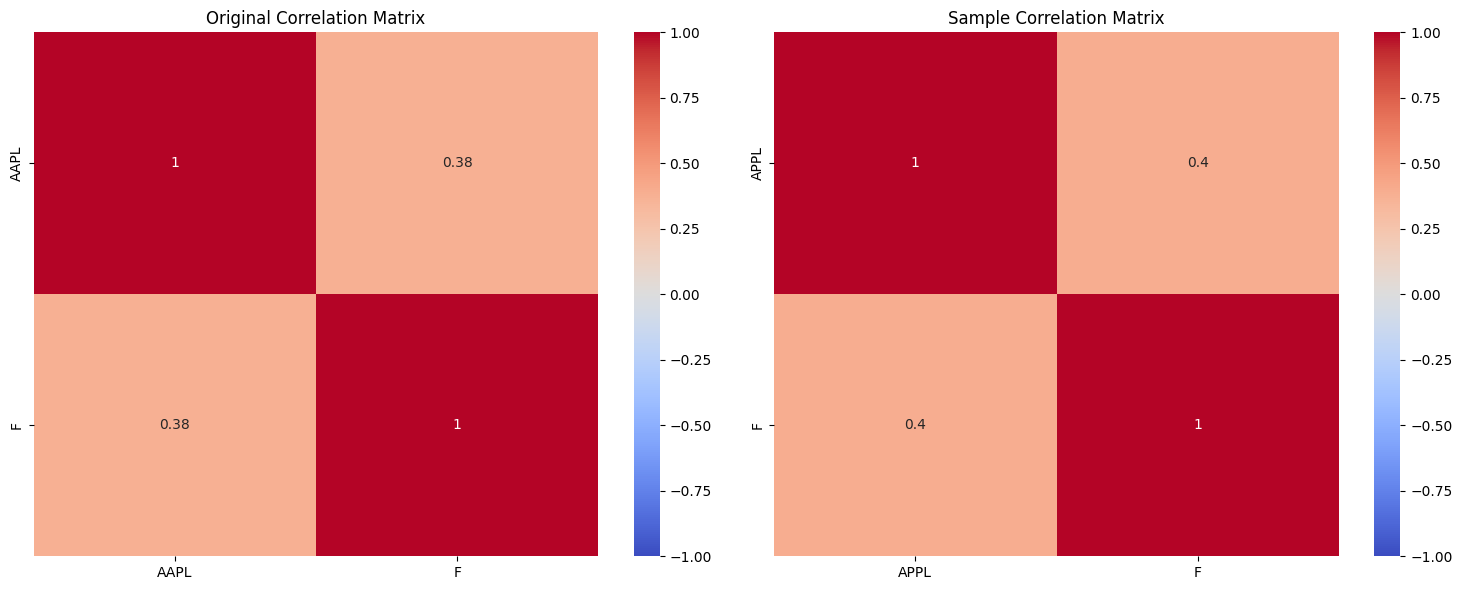

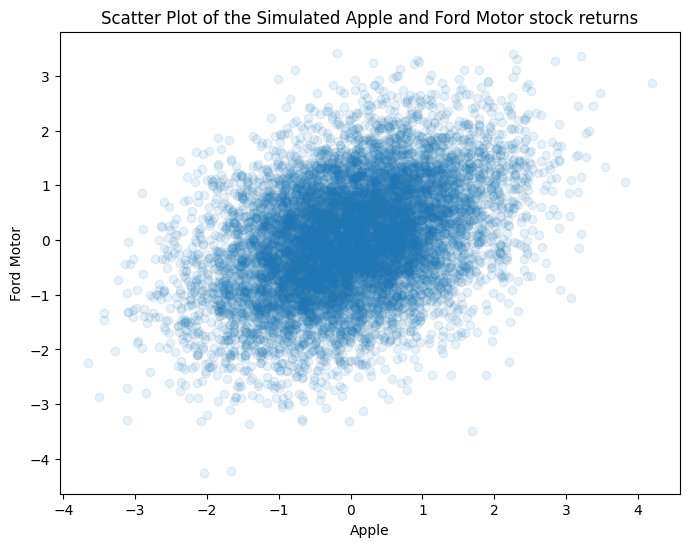

In [15]:
# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(original_correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax1)
ax1.set_title('Original Correlation Matrix')
ax1.set(xlabel='', ylabel='')


sns.heatmap(sample_correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax2)
ax2.set_title('Sample Correlation Matrix')
ax2.set(xlabel='', ylabel='')

plt.tight_layout()
plt.show()

# Scatter plot of the stimulated Apple and Ford Motor stock returns
plt.figure(figsize=(8, 6))
plt.scatter(X["APPL"], X["F"], alpha=0.1)
plt.title('Scatter Plot of the Simulated Apple and Ford Motor stock returns')
plt.xlabel('Apple')
plt.ylabel('Ford Motor')
plt.show()

From the above original correlation matrix and sample correlation matrix, we can see that the correlation values of the original data and the simulated data are very close.
<br>
<br>
## **5. Conclusion**
In this lesson, we introduced a few special matrices and some linear algebra tools related to these matrices. We started with the definition and properties of a symmetric matrix and then its application, especially its diagonalized form. Then, we described what upper and lower triangular matrices are. We moved to symmetric positive definite matrices followed by symmetric positive semidefinite matrices. We finished the lesson by introducing Cholesky factorization. We provided the definition and went through one numeric example. We ended the section with a Cholesky factorization application with a Monte Carlo simulation. All these special matrices will play important roles in the financial analysis tools we are going to learn in future lessons.